# 01 — Analiza danych (EDA): ukryte karty development w Catan

Zbiór uczy model wnioskować o **ukrytych kartach development** obserwowanego gracza
na podstawie publicznie widocznego przebiegu gry. Ten notebook:

1. wczytuje wygenerowane dane (`data/*.parquet`),
2. pokazuje rozkłady, zależności i **kluczowe sygnały** (zwł. `rounds_held`),
3. liczy prosty **baseline** (regresja logistyczna na cechach per-karta).

> Środowisko: `.venv-ml` (Python 3.12). Uruchom kernel z tego venv.
> Dane: 7000 gier, ~5.0 M kroków (`timesteps`), ~692 k próbek per-karta (`card_samples`).

In [1]:
import glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.constrained_layout.use": True,   # automatyczne odstępy — brak nachodzenia
    "axes.titleweight": "semibold",
    "axes.titlepad": 10,
})

DATA = "../data"
LABELS = ["KNIGHT", "VICTORY_POINT", "ROAD_BUILDING", "MONOPOLY", "YEAR_OF_PLENTY"]
SHORT = {"KNIGHT": "Rycerz", "VICTORY_POINT": "Punkt zw.", "ROAD_BUILDING": "Budowa dróg",
         "MONOPOLY": "Monopol", "YEAR_OF_PLENTY": "Rok obfit."}
PALETTE = dict(zip(LABELS, sns.color_palette("Set2", 5)))
print("OK")

OK


## 1. Wczytanie danych

`card_samples` (małe) ładujemy w całości; z `timesteps` (duże) tylko potrzebne kolumny.

In [2]:
card = pd.concat([pd.read_parquet(f) for f in sorted(glob.glob(f"{DATA}/card_samples_*.parquet"))],
                 ignore_index=True)
ts_cols = ["game_id", "action_index", "observed_color", "observed_type", "robber_on_observed",
           "y_knight", "num_turns", "obs_total_dev_bought", "obs_total_dev_played",
           "n_hidden_cards", "is_observed_turn_start"]
ts = pd.concat([pd.read_parquet(f, columns=ts_cols) for f in sorted(glob.glob(f"{DATA}/timesteps_*.parquet"))],
               ignore_index=True)
card["label_pl"] = card.label.map(SHORT)
print("card_samples:", card.shape, "| timesteps:", ts.shape)
print("gry:", ts.game_id.nunique(), "| perspektywy:", ts.groupby(['game_id', 'observed_color']).ngroups)
card.head()

card_samples: (692097, 11) | timesteps: (5019622, 11)


gry: 7000 | perspektywy: 16552


,game_id,action_index,observed_color,observed_type,card_slot,rounds_held,bought_at_action,is_observed_turn_start,n_hidden_cards,label,label_pl
0,2,20,Color.RED,MCTS,0,1,19,0,1,KNIGHT,Rycerz
1,2,21,Color.RED,MCTS,0,2,19,0,1,KNIGHT,Rycerz
2,2,22,Color.RED,MCTS,0,3,19,0,1,KNIGHT,Rycerz
3,2,23,Color.RED,MCTS,0,4,19,0,1,KNIGHT,Rycerz
4,2,24,Color.RED,MCTS,0,5,19,0,1,KNIGHT,Rycerz


## 2. Rozkład klas — skrajne niezbalansowanie

Typ karty to target 5-klasowy. Rozkład jest mocno skośny: dominuje VICTORY_POINT,
a MONOPOLY / YEAR_OF_PLENTY to <2%. Dlatego metryką jest **macro-F1**, nie accuracy.
Słupki poziome — pełne nazwy bez obracania i nachodzenia etykiet.

findfont: Failed to find font weight semibold, now using 700.


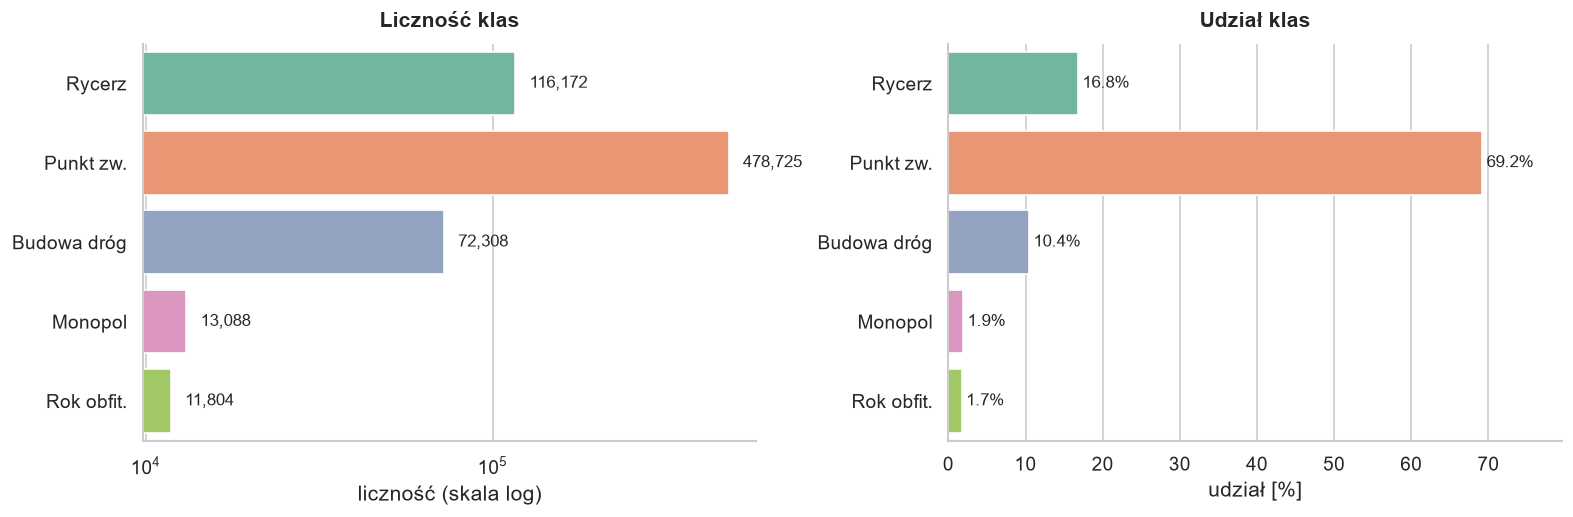

In [3]:
vc = card.label.value_counts().reindex(LABELS)
pct = (vc / vc.sum() * 100)
order_pl = [SHORT[l] for l in LABELS]
colors = [PALETTE[l] for l in LABELS]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(x=vc.values, y=order_pl, hue=order_pl, palette=colors, legend=False, ax=ax[0])
ax[0].set_xscale("log"); ax[0].set_xlabel("liczność (skala log)"); ax[0].set_ylabel("")
ax[0].set_title("Liczność klas")
for i, v in enumerate(vc.values):
    ax[0].text(v * 1.1, i, f"{v:,}", va="center", fontsize=10)

sns.barplot(x=pct.values, y=order_pl, hue=order_pl, palette=colors, legend=False, ax=ax[1])
ax[1].set_xlabel("udział [%]"); ax[1].set_ylabel(""); ax[1].set_xlim(0, pct.max() * 1.15)
ax[1].set_title("Udział klas")
for i, v in enumerate(pct.values):
    ax[1].text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=10)
sns.despine(fig)
plt.show()

## 3. `rounds_held` — najsilniejszy sygnał

Ile akcji karta jest trzymana na ręce. Karty **VICTORY_POINT** trzyma się do końca gry
(nigdy nie zagrywane), więc mają ogromny `rounds_held`; rycerze i year-of-plenty grane
są szybko. To pojedyncza cecha o ogromnej mocy predykcyjnej.

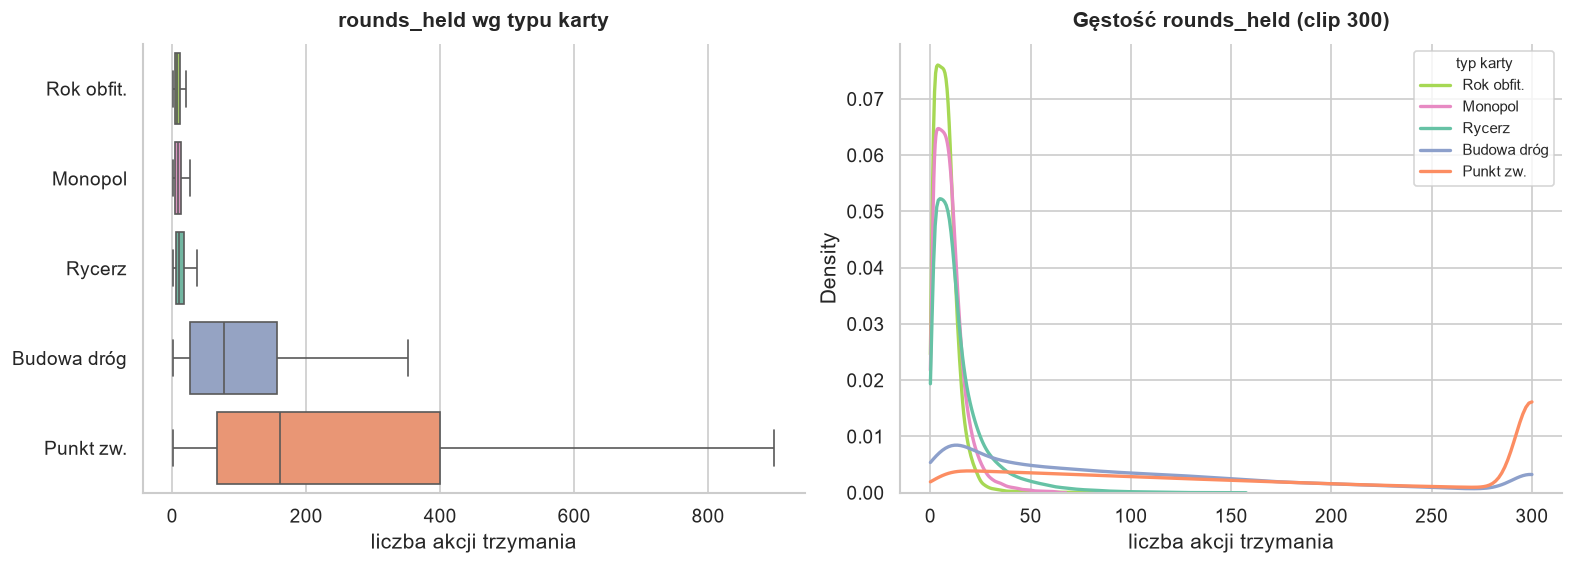

,median,mean,max
label,,,
KNIGHT,10.0,14.7,153
VICTORY_POINT,161.0,341.6,3747
ROAD_BUILDING,78.0,121.2,1368
MONOPOLY,8.0,9.8,64
YEAR_OF_PLENTY,7.0,8.2,100


In [4]:
order = card.groupby("label").rounds_held.median().sort_values().index.tolist()
order_pl = [SHORT[l] for l in order]
pal_order = [PALETTE[l] for l in order]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
sns.boxplot(data=card, y="label_pl", x="rounds_held", order=order_pl,
            hue="label_pl", palette={SHORT[l]: PALETTE[l] for l in LABELS},
            legend=False, showfliers=False, ax=ax[0])
ax[0].set_title("rounds_held wg typu karty"); ax[0].set_xlabel("liczba akcji trzymania"); ax[0].set_ylabel("")

for l in order:
    sns.kdeplot(card.loc[card.label == l, "rounds_held"].clip(upper=300),
                label=SHORT[l], color=PALETTE[l], ax=ax[1], lw=2, clip=(0, 300))
ax[1].set_title("Gęstość rounds_held (clip 300)"); ax[1].set_xlabel("liczba akcji trzymania")
ax[1].legend(title="typ karty", fontsize=9, title_fontsize=9, loc="upper right")
sns.despine(fig)
plt.show()
display(card.groupby("label").rounds_held.agg(["median", "mean", "max"]).reindex(LABELS).round(1))

## 4. Perspektywy: typ obserwowanego bota i podział seen/unseen

Obserwowani to wyłącznie silne boty (ValueFunction, AlphaBeta, MCTS). W podziale danych
gry z **MCTS przy stole** trafiają w całości do testu jako *niewidziany styl* (`unseen_mcts`).

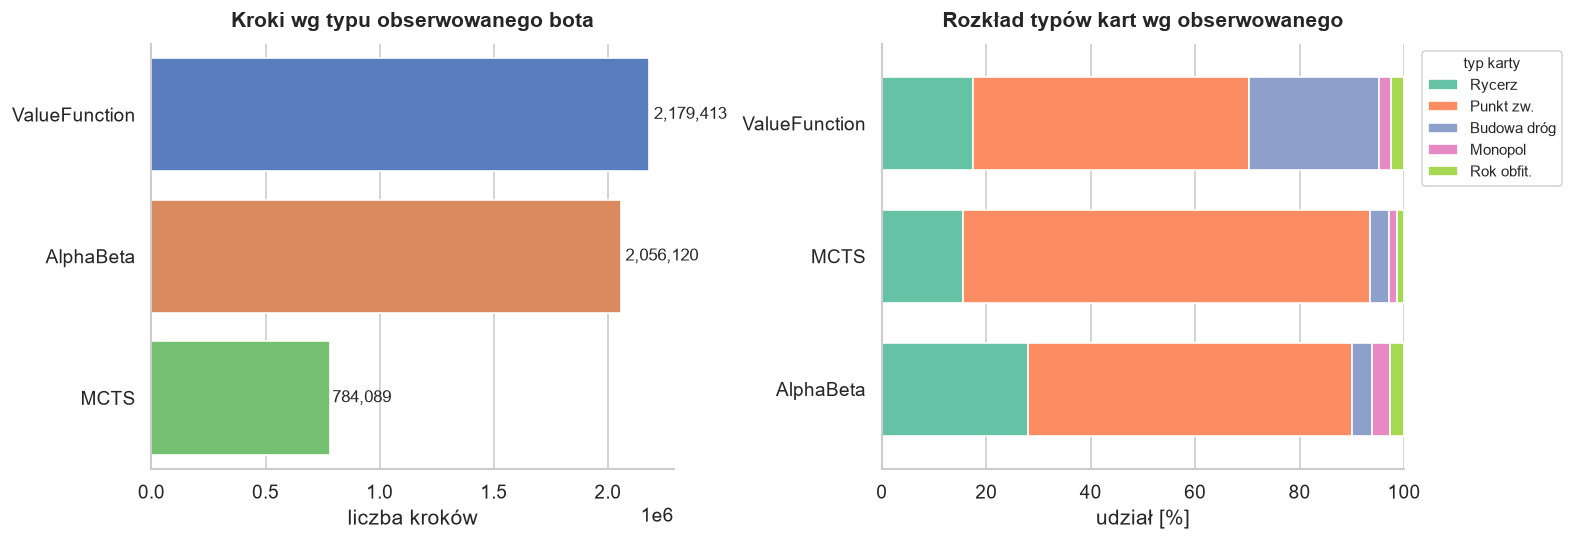

In [5]:
obs_counts = ts.observed_type.value_counts()
ct = card.groupby(["observed_type", "label"]).size().unstack().reindex(columns=LABELS)
ct_pct = ct.div(ct.sum(1), axis=0) * 100
ct_pct.columns = [SHORT[c] for c in ct_pct.columns]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
sns.barplot(x=obs_counts.values, y=obs_counts.index, hue=obs_counts.index,
            palette="muted", legend=False, ax=ax[0])
ax[0].set_title("Kroki wg typu obserwowanego bota"); ax[0].set_xlabel("liczba kroków"); ax[0].set_ylabel("")
for i, v in enumerate(obs_counts.values):
    ax[0].text(v * 1.01, i, f"{v:,}", va="center", fontsize=10)

ct_pct.plot(kind="barh", stacked=True, ax=ax[1],
            color=[PALETTE[l] for l in LABELS], width=0.7)
ax[1].set_title("Rozkład typów kart wg obserwowanego"); ax[1].set_xlabel("udział [%]"); ax[1].set_ylabel("")
ax[1].set_xlim(0, 100)
ax[1].legend(title="typ karty", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title_fontsize=9)
sns.despine(fig)
plt.show()

## 5. Złodziej (robber) a posiadanie rycerza

Hipoteza z implementacji: jeśli złodziej blokuje obserwowanego, a ten **nie zagrał** rycerza,
to maleje prawdopodobieństwo, że rycerza w ogóle ma. Sprawdźmy zależność `robber_on_observed`
od liczby rycerzy na ręce (`y_knight`).

,p_ma_rycerza,srednio_rycerzy,udzial_krokow
robber_on_observed,,,
0,0.022,0.024,66.3
1,0.020,0.021,33.7


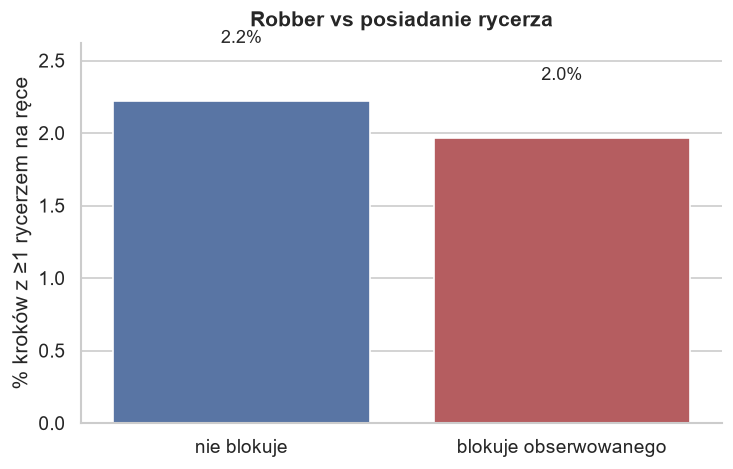

In [6]:
g = ts.groupby("robber_on_observed").agg(
        p_ma_rycerza=("y_knight", lambda s: (s > 0).mean()),
        srednio_rycerzy=("y_knight", "mean"),
        udzial_krokow=("y_knight", "size"))
g["udzial_krokow"] = (g["udzial_krokow"] / len(ts) * 100).round(1)
display(g.round(3))

plot_df = pd.DataFrame({
    "Złodziej": ["nie blokuje", "blokuje obserwowanego"],
    "p": (g["p_ma_rycerza"] * 100).values})
fig, ax = plt.subplots(figsize=(6, 3.8))
sns.barplot(data=plot_df, x="Złodziej", y="p", hue="Złodziej",
            palette=["#4c72b0", "#c44e52"], legend=False, ax=ax)
ax.set_ylabel("% kroków z ≥1 rycerzem na ręce"); ax.set_xlabel("")
ax.set_title("Robber vs posiadanie rycerza")
for i, v in enumerate(plot_df.p):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, plot_df.p.max() * 1.18)
sns.despine(fig)
plt.show()

## 6. Długość sekwencji i postęp gry

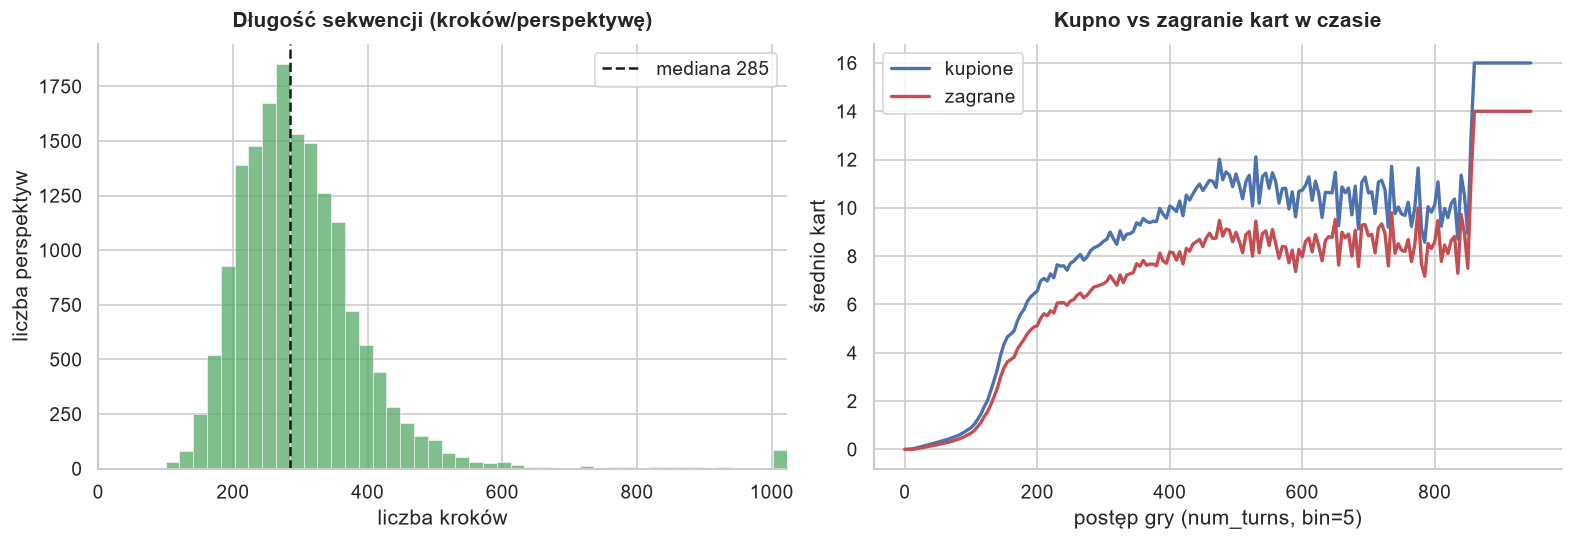

In [7]:
seqlen = ts.groupby(["game_id", "observed_color"]).size()
prog = ts.copy()
prog["faza"] = (prog.num_turns // 5 * 5)
prog_long = prog.melt(id_vars="faza", value_vars=["obs_total_dev_bought", "obs_total_dev_played"],
                      var_name="rodzaj", value_name="liczba")
prog_long["rodzaj"] = prog_long["rodzaj"].map(
    {"obs_total_dev_bought": "kupione", "obs_total_dev_played": "zagrane"})

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
sns.histplot(seqlen.clip(upper=int(seqlen.quantile(0.995))), bins=45, color="#55a868",
             ax=ax[0], edgecolor="white", linewidth=0.3)
ax[0].axvline(seqlen.median(), color="k", ls="--", lw=1.5, label=f"mediana {seqlen.median():.0f}")
ax[0].set_xlim(0, seqlen.quantile(0.995))
ax[0].set_title("Długość sekwencji (kroków/perspektywę)"); ax[0].set_xlabel("liczba kroków")
ax[0].set_ylabel("liczba perspektyw"); ax[0].legend()

sns.lineplot(data=prog_long, x="faza", y="liczba", hue="rodzaj",
             palette=["#4c72b0", "#c44e52"], errorbar=None, lw=2, ax=ax[1])
ax[1].set_xlabel("postęp gry (num_turns, bin=5)"); ax[1].set_ylabel("średnio kart")
ax[1].set_title("Kupno vs zagranie kart w czasie"); ax[1].legend(title="")
sns.despine(fig)
plt.show()

## 7. Baseline: regresja logistyczna na cechach per-karta

Bez sekwencji, bez enkodera — sama regresja logistyczna na jawnych cechach pojedynczej
karty (głównie `rounds_held`). To **dolny punkt odniesienia** dla metod uczenia
reprezentacji z notebooka 02. Pokazuje, jak daleko zaprowadzi sam `rounds_held`.

macro-F1: 0.302


                precision    recall  f1-score   support

        KNIGHT      0.413     0.305     0.351      6059
      MONOPOLY      0.077     0.237     0.117       678
 ROAD_BUILDING      0.168     0.537     0.256      3747
 VICTORY_POINT      0.941     0.485     0.640     24896
YEAR_OF_PLENTY      0.082     0.616     0.144       620

      accuracy                          0.458     36000
     macro avg      0.336     0.436     0.302     36000
  weighted avg      0.741     0.458     0.533     36000



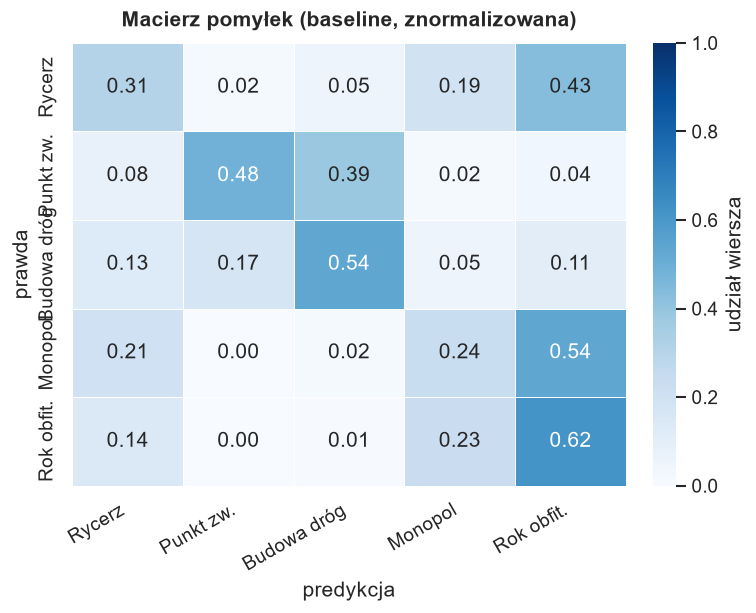

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

FEATS = ["rounds_held", "n_hidden_cards", "card_slot", "bought_at_action", "is_observed_turn_start"]
d = card.sample(min(120000, len(card)), random_state=0)
X = StandardScaler().fit_transform(d[FEATS]); y = d.label
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, ytr)
pred = clf.predict(Xte)
print("macro-F1:", round(f1_score(yte, pred, average="macro"), 3))
print(classification_report(yte, pred, digits=3))

cm = confusion_matrix(yte, pred, labels=LABELS, normalize="true")
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=[SHORT[l] for l in LABELS], yticklabels=[SHORT[l] for l in LABELS],
            cbar_kws={"label": "udział wiersza"}, ax=ax, linewidths=0.5, linecolor="white")
ax.set_title("Macierz pomyłek (baseline, znormalizowana)")
ax.set_xlabel("predykcja"); ax.set_ylabel("prawda")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

## Wnioski z EDA

- **Skrajne niezbalansowanie** → macro-F1 + ważenie klas to konieczność.
- **`rounds_held`** to dominujący sygnał: oddziela VICTORY_POINT (trzymane do końca) od reszty.
- **MONOPOLY / YEAR_OF_PLENTY** (<2%) są trudne — mało próbek, F1 niestabilny.
- **robber_on_observed** niesie informację o rycerzach (sygnał kontekstowy).
- Sekwencje mają ~300 kroków → naturalny **szereg czasowy** dla enkodera (notebook 02).

Baseline per-karta wykorzystuje tylko cechy *jednej* karty. Notebook **02** sprawdza,
czy **reprezentacja całej sekwencji gry** (InfoNCE / Barlow Twins / Transformer) poprawia
predykcję — zwłaszcza dla rzadkich klas i niewidzianego stylu (MCTS).